In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
filepath = "./Libro2.xlsx"

In [8]:
df = pd.read_excel(filepath, names=["date", "q0", "q1", "q2", "q3", "Q0", "Q1", "Q2", "Q3"])

In [11]:
df["q1"] = df["q1"].dropna()


In [17]:
df = df[~np.isnan(df["q2"])]
df

,date,q0,q1,q2,q3,Q0,Q1,Q2,Q3,Fecha
0,"2024-09-01 12:57:18,135",1.0,0.000216,-0.000688,2.042924e-09,1.000000,0.000105,-0.000343,4.502997e-16,2024-09-01 12:57:18
1,"2024-09-01 12:57:18,142",0.999999,0.000323,-0.001015,-8.777479e-10,1.000000,0.000211,-0.000670,-2.425406e-09,2024-09-01 12:57:18
2,"2024-09-01 12:57:18,180",0.999999,0.000425,-0.001330,-2.836096e-09,0.999999,0.000313,-0.000985,-4.198469e-09,2024-09-01 12:57:18
3,"2024-09-01 12:57:18,181",0.999999,0.000526,-0.001645,-4.227878e-09,0.999999,0.000415,-0.001300,-5.551163e-09,2024-09-01 12:57:18
4,"2024-09-01 12:57:18,181",0.999998,0.000628,-0.001940,-1.684131e-08,0.999999,0.000517,-0.001595,-1.575447e-08,2024-09-01 12:57:18
...,...,...,...,...,...,...,...,...,...,...
361121,"2024-09-01 14:04:50,019",0.999987,0.004968,-0.000796,5.980060e-07,0.999988,0.004937,-0.000792,5.899626e-07,2024-09-01 14:04:50
361122,"2024-09-01 14:04:50,033",0.999987,0.004968,-0.000796,5.980060e-07,0.999988,0.004937,-0.000792,5.899626e-07,2024-09-01 14:04:50
361123,"2024-09-01 14:04:50,050",0.999987,0.004968,-0.000796,5.980060e-07,0.999988,0.004937,-0.000792,5.899626e-07,2024-09-01 14:04:50
361124,"2024-09-01 14:04:50,054",0.999987,0.004968,-0.000796,5.980060e-07,0.999988,0.004937,-0.000792,5.899626e-07,2024-09-01 14:04:50


In [12]:

# Asegurarse de que la columna Fecha es de tipo datetime
df["Fecha"] = pd.to_datetime(df["date"])
df

/tmp/ipykernel_1603186/2733399729.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Fecha"] = pd.to_datetime(df["date"])


,date,q0,q1,q2,q3,Q0,Q1,Q2,Q3,Fecha
0,"2024-09-01 12:57:18,135",1.0,0.000216,-0.000688,2.042924e-09,1.000000,0.000105,-0.000343,4.502997e-16,2024-09-01 12:57:18
1,"2024-09-01 12:57:18,142",0.999999,0.000323,-0.001015,-8.777479e-10,1.000000,0.000211,-0.000670,-2.425406e-09,2024-09-01 12:57:18
2,"2024-09-01 12:57:18,180",0.999999,0.000425,-0.001330,-2.836096e-09,0.999999,0.000313,-0.000985,-4.198469e-09,2024-09-01 12:57:18
3,"2024-09-01 12:57:18,181",0.999999,0.000526,-0.001645,-4.227878e-09,0.999999,0.000415,-0.001300,-5.551163e-09,2024-09-01 12:57:18
4,"2024-09-01 12:57:18,181",0.999998,0.000628,-0.001940,-1.684131e-08,0.999999,0.000517,-0.001595,-1.575447e-08,2024-09-01 12:57:18
...,...,...,...,...,...,...,...,...,...,...
800010,"2024-09-01 16:09:51,804","Q SENSOR: quaternion(0,999867737293243, 0,0007...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-01 16:09:51
800011,"2024-09-01 16:09:51,812","Q SENSOR: quaternion(0,999867737293243, 0,0007...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-01 16:09:51
800012,"2024-09-01 16:09:51,819","Q SENSOR: quaternion(0,999867737293243, 0,0007...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-01 16:09:51
800013,"2024-09-01 16:09:51,835","Q SENSOR: quaternion(0,999867737293243, 0,0007...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-01 16:09:51


In [25]:
metrics = {}
for col in ["q0", "q1", "q2", "q3"]:
    initial_value = df[col].iloc[0]
    final_value = df[col].iloc[-1]
    min_value = df[col].min()
    max_value = df[col].max()
    std_dev = df[col].std()
    absolute_error = df[col].diff().abs().sum()

    metrics[col] = {
        "Valor Inicial": initial_value,
        "Valor Final": final_value,
        "Valor mínimo": min_value,
        "Valor máximo": max_value,
        "Diferencia": max_value - min_value,
        "Desviación Típica": std_dev,
        "Error Absoluto": absolute_error,
    }

In [32]:
2.158555e-04 - 4.968393e-04

-0.0002809838

Métricas calculadas:
    Valor Inicial   Valor Final  Valor mínimo  Valor máximo  Diferencia  \
q0   9.999998e-01  9.999874e-01      0.000114      1.000000    0.999886   
q1   2.158555e-04  4.968393e-03     -0.665987      0.324401    0.990388   
q2  -6.882333e-04 -7.956364e-04     -0.210567      0.442052    0.652619   
q3   2.042924e-09  5.980060e-07     -0.999918      0.999910    1.999828   

    Desviación Típica  Error Absoluto  
q0           0.041802        6.770889  
q1           0.011157        3.528290  
q2           0.005739        2.817781  
q3           0.077347        9.607369  


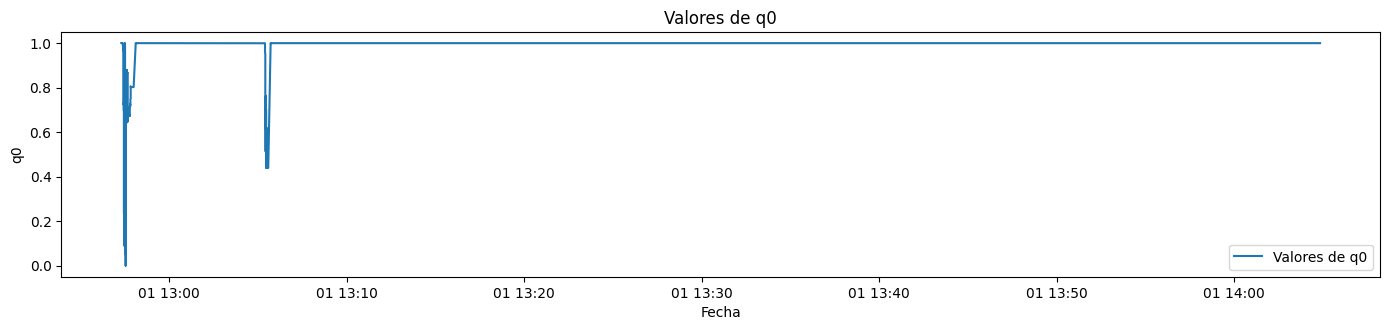

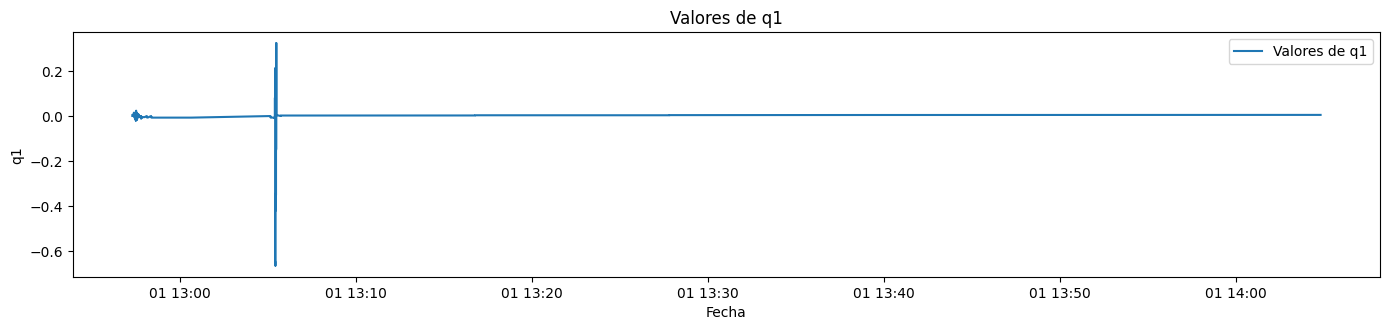

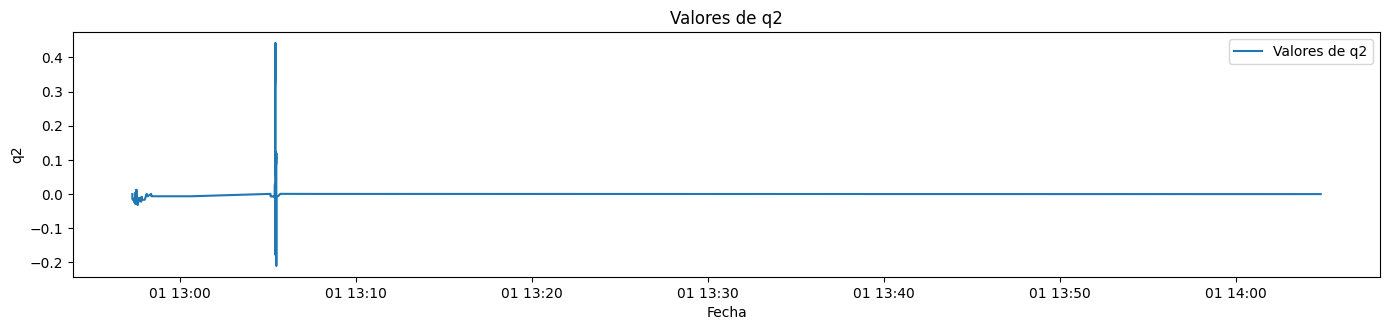

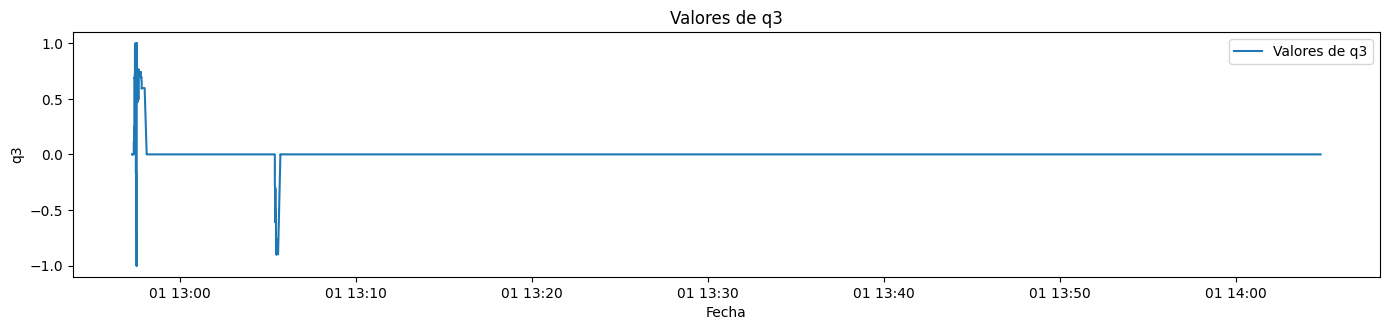

In [26]:
metrics_df = pd.DataFrame(metrics).T
print("Métricas calculadas:")
print(metrics_df)

# Graficar los valores y las derivadas
for col in ["q0", "q1", "q2", "q3"]:
    plt.figure(figsize=(14, 6))

    # Graficar los valores
    plt.subplot(2, 1, 1)
    plt.plot(df["Fecha"], df[col], label=f"Valores de {col}")
    plt.title(f"Valores de {col}")
    plt.xlabel("Fecha")
    plt.ylabel(col)
    plt.legend()

    # Calcular y graficar la derivada
    # derivative = df[col].diff()
    # plt.subplot(2, 1, 2)
    # plt.plot(df["Fecha"], derivative, label=f"Derivada de {col}", color="red")
    # plt.title(f"Variación de {col} (Derivada)")
    # plt.xlabel("Fecha")
    # plt.ylabel(f"Derivada de {col}")
    # plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
metrics_df.to_excel("metrics_output.xlsx", index=True)